In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold
from collections import Counter
import heapq
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Quality distribution:\n{train_df['quality'].value_counts().sort_index()}")

Train shape: (857, 13)
Test shape: (286, 12)
Quality distribution:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


### EDA

In [ ]:
train_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [ ]:
test_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


In [ ]:
print("\nTraining Data Info")
train_df.info()

print("\nMissing Values in Training Data")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Data")
print(test_df.isnull().sum())

print("\nTraining Data Statistical Summary")
display(train_df.describe())



Training Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

Missing Values in Training Data
fixed acidity           0

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


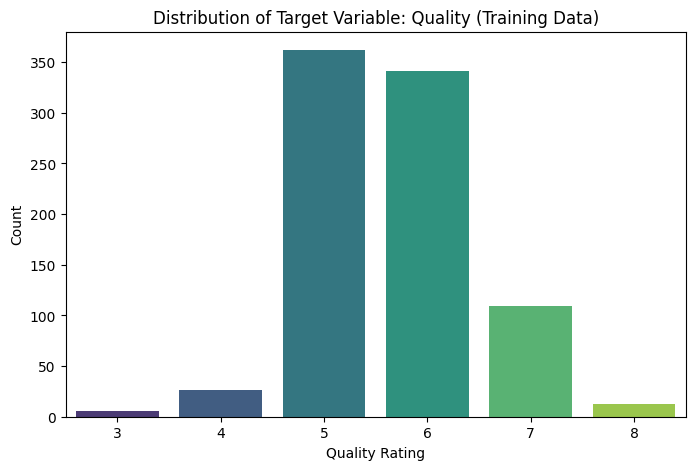

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='quality', palette='viridis')
plt.title('Distribution of Target Variable: Quality (Training Data)')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.show()

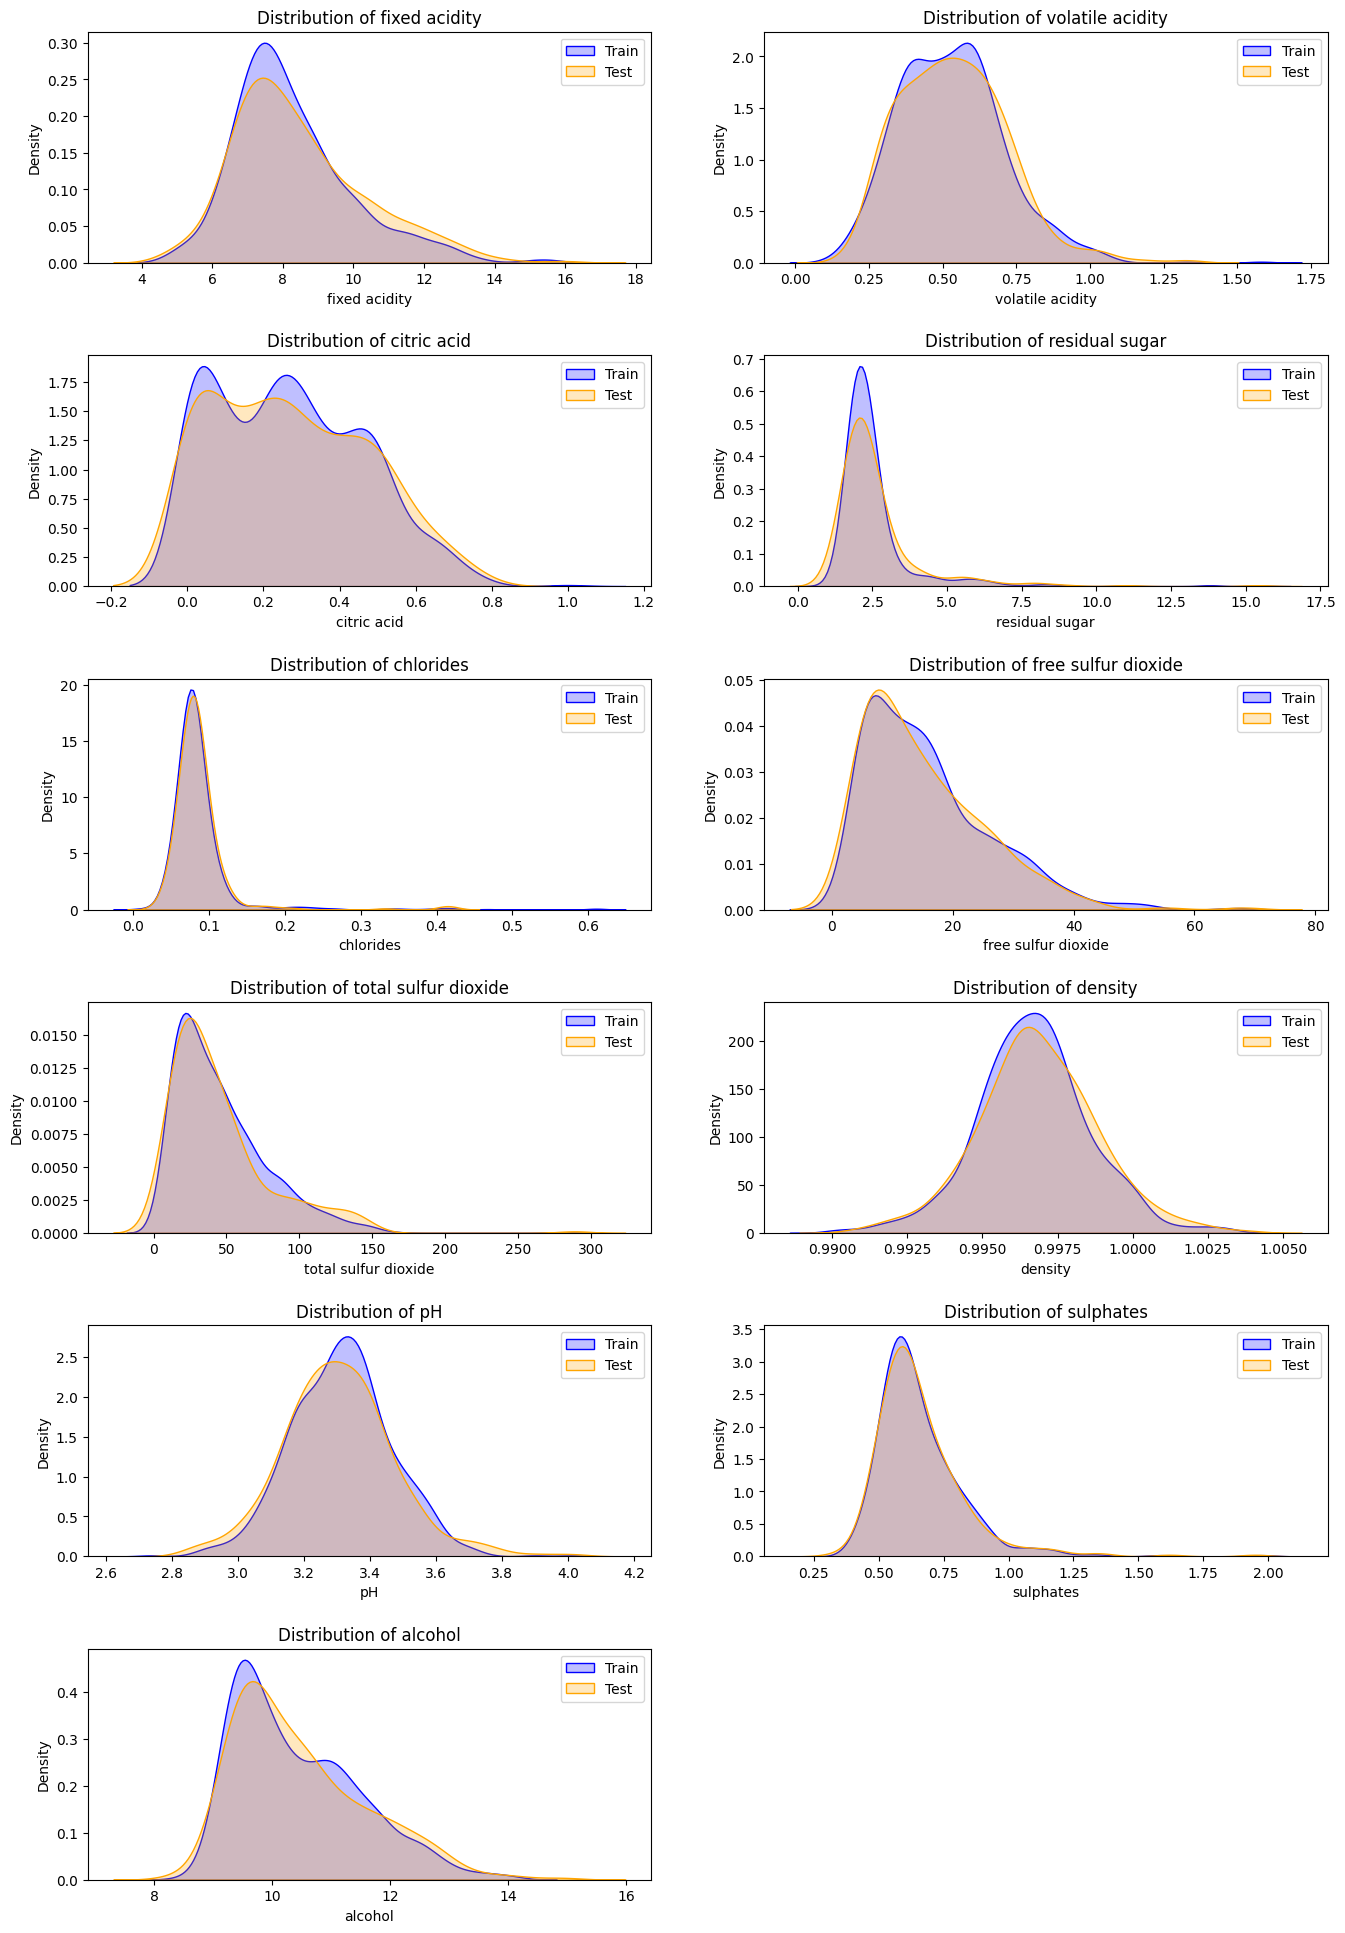

In [ ]:
features = [col for col in train_df.columns if col not in ['Id', 'quality']]

fig, axes = plt.subplots(nrows=(len(features) + 1) // 2, ncols=2, figsize=(16, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.2)
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(train_df[feature], ax=axes[i], fill=True, color='blue', label='Train')

    if feature in test_df.columns:
        sns.kdeplot(test_df[feature], ax=axes[i], fill=True, color='orange', label='Test')

    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

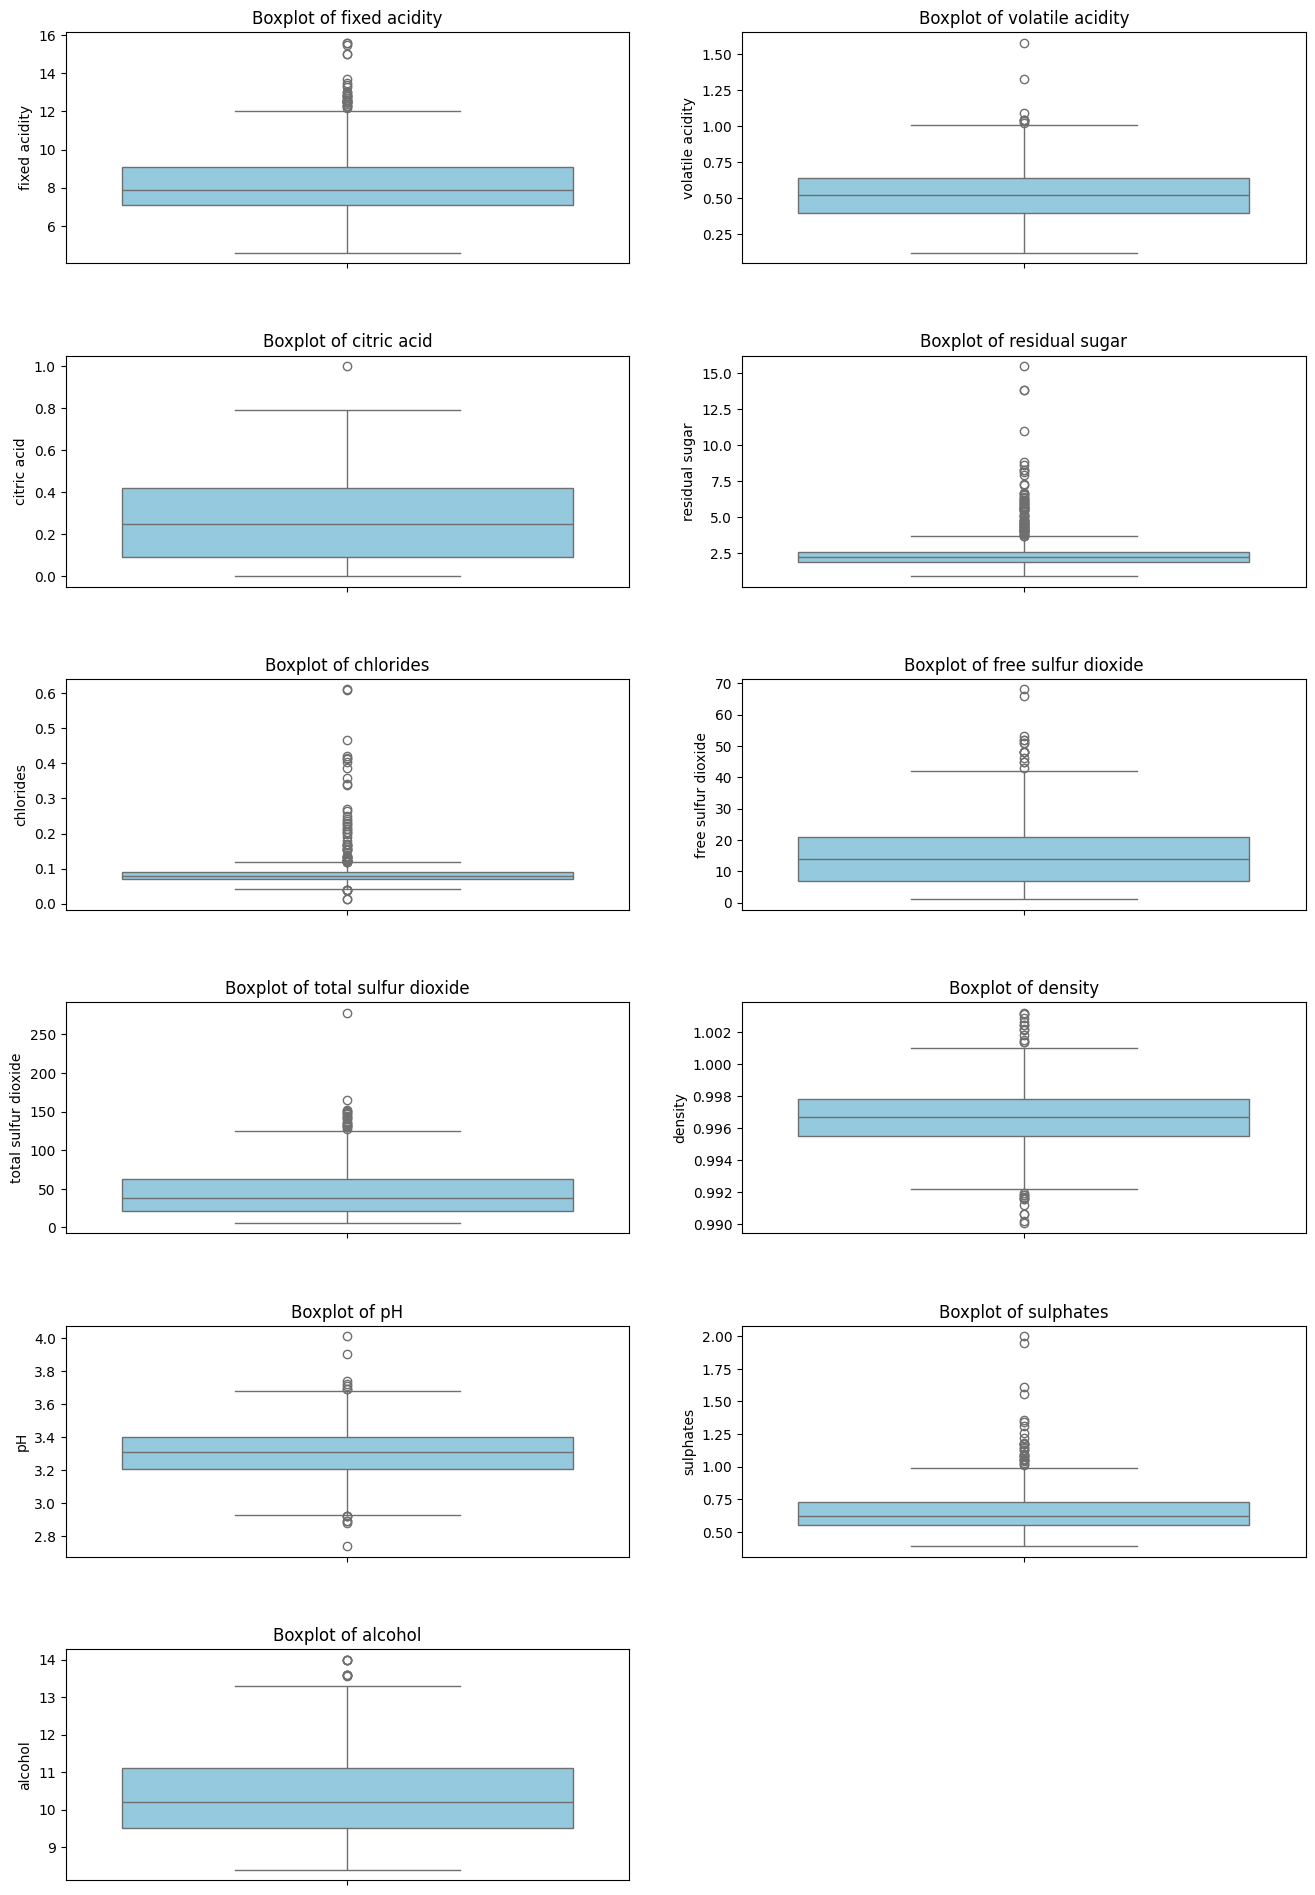

In [ ]:
fig, axes = plt.subplots(nrows=(len(features) + 1) // 2, ncols=2, figsize=(16, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.2)
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(y=train_df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

### Preprocessing

#### Handling Missing Value w winsorization

In [31]:
def get_iqr_bounds(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

def apply_bounds(df, column, lower, upper):
    df[column] = np.clip(df[column], lower, upper)
    return df

bounds_dict = {}

for col in feature_cols:
    lower, upper = get_iqr_bounds(train_df, col)
    bounds_dict[col] = (lower, upper)
    train_df = apply_bounds(train_df, col, lower, upper)

for col in feature_cols:
    lower, upper = bounds_dict[col]
    test_df = apply_bounds(test_df, col, lower, upper)

print('Hidup Jokowi!')

Hidup Jokowi!


#### Splitting

In [32]:
X = train_df[feature_cols].values
y = train_df['quality'].values
X_test_final = test_df[feature_cols].values
test_ids = test_df['Id'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (685, 11), Val: (172, 11)


## SMOTEWB-LGBM

This model was adopted from: https://onlinelibrary.wiley.com/doi/epdf/10.1155/2024/3493676

In [21]:
from lightgbm import LGBMClassifier
from smote_variants import SMOTEWB
import optuna
from collections import Counter
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [23]:
def successive_smotewb(X, y):
    classes, counts = np.unique(y, return_counts=True)
    order = np.argsort(-counts)
    classes_sorted = classes[order]
    max_count = counts[order[0]]

    X_res, y_res = X.copy(), y.copy()

    print(f"\nTarget samples per class: {max_count}")
    print("-" * 50)

    for i in range(1, len(classes_sorted)):
        minority_cls = classes_sorted[i]
        minority_mask = y_res == minority_cls
        X_min = X_res[minority_mask]
        current_count = len(X_min)
        n_to_generate = max_count - current_count

        if n_to_generate <= 0:
            print(f"  Class {minority_cls}: sudah cukup ({current_count} samples), skip")
            continue

        print(f"  Class {minority_cls}: {current_count} → target {max_count} (generate {n_to_generate})")

        majority_mask = y_res == classes_sorted[0]
        X_maj_all = X_res[majority_mask]

        max_maj = min(len(X_maj_all), current_count * 10)
        idx = np.random.choice(len(X_maj_all), max_maj, replace=False)
        X_maj_sub = X_maj_all[idx]

        y_maj = np.zeros(len(X_maj_sub), dtype=int)
        y_min_bin = np.ones(current_count, dtype=int)
        X_bin = np.vstack([X_maj_sub, X_min])
        y_bin = np.concatenate([y_maj, y_min_bin])
        proportion = (len(X_maj_sub) + n_to_generate) / len(X_maj_sub)
        k = max(1, min(5, current_count - 1))

        try:
            smote = SMOTEWB(
                proportion=proportion,
                n_neighbors=k,
                n_jobs=1
            )
            X_bin_res, y_bin_res = smote.fit_resample(X_bin, y_bin)
            new_samples = X_bin_res[y_bin_res == 1][current_count:]

            if len(new_samples) == 0:
                print(f"    SMOTEWB tidak generate sample untuk class {minority_cls}")
                idx_fallback = np.random.choice(current_count, n_to_generate, replace=True)
                new_samples = X_min[idx_fallback]
            else:
                new_samples = new_samples[:n_to_generate]

            X_res = np.vstack([X_res, new_samples])
            y_res = np.concatenate([y_res, np.full(len(new_samples), minority_cls)])
            print(f"    Added {len(new_samples)} samples")

        except Exception as e:
            print(f"    Error class {minority_cls}: {e}")
            print(f"    Fallback: random oversampling")
            idx_fallback = np.random.choice(current_count, n_to_generate, replace=True)
            new_samples = X_min[idx_fallback]
            X_res = np.vstack([X_res, new_samples])
            y_res = np.concatenate([y_res, np.full(n_to_generate, minority_cls)])

    return X_res, y_res

The successive_smotewb function implements a sequential resampling strategy to handle class imbalance in the training data. It applies Synthetic Minority Oversampling Technique (SMOTE) to generate synthetic samples for minority classes based on feature space interpolation between nearest neighbors. This step is followed by a cleaning process, such as Tomek Links removal, which eliminates overlapping instances between classes to reduce noise and class ambiguity. The procedure may be performed iteratively to progressively balance the class distribution while maintaining data quality. By combining oversampling and undersampling techniques in a controlled sequence, this function improves the representativeness of minority classes and enhances the robustness of the model during training.

In [24]:
np.random.seed(2)
print("Menjalankan Successive SMOTEWB...")
X_train_res, y_train_res = successive_smotewb(X_train, y_train)

print("\n" + "=" * 50)
print("Distribusi class after SMOTE:")
print("=" * 50)
counter_after = Counter(y_train_res)
for cls in sorted(counter_after.keys()):
    before = Counter(y_train).get(cls, 0)
    added = counter_after[cls] - before
    bar = "█" * (counter_after[cls] // 5)
    print(f"  Class {cls:>2}: {counter_after[cls]:>4} samples  (+{added:<4})  {bar}")
print(f"\n  Total: {len(y_train_res)} samples")

2026-04-30 13:52:11,308:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.055363321799308), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.055363321799308), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 13:52:11,316:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling


Menjalankan Successive SMOTEWB...

Target samples per class: 289
--------------------------------------------------
  Class 6: 273 → target 289 (generate 16)


2026-04-30 13:52:12,046:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-30 13:52:12,054:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-30 13:52:12,066:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.698961937716263), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.698961937716263), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 13:52:12,069:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling
2026-04-30 13:52:12,086:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWith

    Added 16 samples
  Class 7: 87 → target 289 (generate 202)
    Added 202 samples
  Class 4: 21 → target 289 (generate 268)
    Added 268 samples
  Class 8: 10 → target 289 (generate 279)
    Added 279 samples
  Class 3: 5 → target 289 (generate 284)
    Added 284 samples

Distribusi class after SMOTE:
  Class  3:  289 samples  (+284 )  █████████████████████████████████████████████████████████
  Class  4:  289 samples  (+268 )  █████████████████████████████████████████████████████████
  Class  5:  289 samples  (+0   )  █████████████████████████████████████████████████████████
  Class  6:  289 samples  (+16  )  █████████████████████████████████████████████████████████
  Class  7:  289 samples  (+202 )  █████████████████████████████████████████████████████████
  Class  8:  289 samples  (+279 )  █████████████████████████████████████████████████████████

  Total: 1734 samples


In [27]:
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'num_leaves': trial.suggest_int('num_leaves', 3, 128),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
        'class_weight': 'balanced',
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
        X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]
        X_fold_res, y_fold_res = successive_smotewb(X_fold_train, y_fold_train)
        clf = LGBMClassifier(**params)
        clf.fit(X_fold_res, y_fold_res)
        y_pred_fold = clf.predict(X_fold_val)
        score = f1_score(y_fold_val, y_pred_fold, average='macro', zero_division=0)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best Macro-F1 (CV): {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_params = study.best_params
best_params.update({'random_state': 42, 'verbose': -1, 'n_jobs': -1, 'class_weight': 'balanced'})

  0%|          | 0/50 [00:00<?, ?it/s]

2026-04-30 14:12:49,358:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.0562770562770563), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.0562770562770563), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 14:12:49,364:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling



Target samples per class: 231
--------------------------------------------------
  Class 6: 218 → target 231 (generate 13)


2026-04-30 14:12:49,749:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-30 14:12:49,753:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-30 14:12:49,765:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.696969696969697), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.696969696969697), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 14:12:49,767:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling
2026-04-30 14:12:49,785:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWith

    Added 13 samples
  Class 7: 70 → target 231 (generate 161)
    Added 161 samples
  Class 4: 17 → target 231 (generate 214)
    Added 214 samples
  Class 8: 8 → target 231 (generate 223)
    Added 223 samples
  Class 3: 4 → target 231 (generate 227)
    Added 227 samples


...


Target samples per class: 231
--------------------------------------------------
  Class 6: 219 → target 231 (generate 12)
    Added 12 samples
  Class 7: 69 → target 231 (generate 162)
    Added 162 samples
  Class 4: 17 → target 231 (generate 214)
    Added 214 samples
  Class 8: 8 → target 231 (generate 223)
    Added 223 samples
  Class 3: 4 → target 231 (generate 227)
    Added 227 samples


2026-04-30 14:28:57,300:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.0603448275862069), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.0603448275862069), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 14:28:57,302:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling
2026-04-30 14:28:57,412:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-30 14:28:57,416:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-30 14:28:57,426:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(1.6982758620689655), 'max_depth': 30


Target samples per class: 232
--------------------------------------------------
  Class 6: 218 → target 232 (generate 14)
    Added 14 samples
  Class 7: 70 → target 232 (generate 162)
    Added 162 samples
  Class 4: 16 → target 232 (generate 216)
    Added 216 samples
  Class 8: 8 → target 232 (generate 224)


2026-04-30 14:28:57,500:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(3.8), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
INFO:smote_variants:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(3.8), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_state': None, 'class_name': 'SMOTEWB'}")
2026-04-30 14:28:57,503:INFO:SMOTEWB: sampling
INFO:smote_variants:SMOTEWB: sampling
2026-04-30 14:28:57,508:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-30 14:28:57,511:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-30 14:28:57,520:INFO:SMOTEWB: Running sampling via ('SMOTEWB', "{'proportion': np.float64(6.7), 'max_depth': 30, 'nn_params': {}, 'n_iters': 100, 'random_st

    Added 224 samples
  Class 3: 4 → target 232 (generate 228)
    Added 228 samples
Best Macro-F1 (CV): 0.3488
Best params:
  n_estimators: 925
  num_leaves: 27
  learning_rate: 0.03736025994993535
  lambda_l1: 0.8621646254578147
  lambda_l2: 6.936798453961418
  feature_fraction: 0.810327250908071
  bagging_fraction: 0.8841621150843714
  bagging_freq: 3
  min_child_samples: 5


The objective function is designed to evaluate the performance of a machine learning model under different hyperparameter configurations during the optimization process. It takes a set of hyperparameters as input, trains the model using the training data, and then assesses its performance using a predefined evaluation metric, such as accuracy or F1-score. The function returns this performance metric, which is then used by the optimization algorithm to determine the quality of the given hyperparameter combination. By repeatedly calling this function with various parameter values, the optimization process aims to identify the set of hyperparameters that yields the best model performance.

In [28]:
counter = Counter(y_train_res)
total = sum(counter.values())
n_classes = len(counter)

class_weight_dict = {
    cls: total / (n_classes * count)
    for cls, count in counter.items()
}

rare_classes = [3, 4, 8]
for cls in rare_classes:
    if cls in class_weight_dict:
        class_weight_dict[cls] *= 3

print("Class weights yang dipakai:")
for cls in sorted(class_weight_dict.keys()):
    print(f"  Class {cls}: {class_weight_dict[cls]:.4f}")

Class weights yang dipakai:
  Class 3: 3.0000
  Class 4: 3.0000
  Class 5: 1.0000
  Class 6: 1.0000
  Class 7: 1.0000
  Class 8: 3.0000


In [29]:
final_model = LGBMClassifier(**best_params)
final_model.fit(
    X_train_res, y_train_res,
    sample_weight=[class_weight_dict[c] for c in y_train_res]
)

y_pred_val = final_model.predict(X_val)

print("\n" + "=" * 50)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print("=" * 50)
print(classification_report(y_val, y_pred_val, zero_division=0))


Validation Accuracy: 0.6047
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.77      0.72        73
           6       0.59      0.57      0.58        68
           7       0.47      0.36      0.41        22
           8       0.50      0.33      0.40         3

    accuracy                           0.60       172
   macro avg       0.37      0.34      0.35       172
weighted avg       0.59      0.60      0.59       172



### Testing

In [33]:
y_test_pred = final_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'Id': test_ids,
    'quality': y_test_pred
})

submission.to_csv('hasilprediksi_011.csv', index=False)

In [34]:
submission['quality'].value_counts()

,count
quality,
5,125
6,119
7,27
4,8
8,5
3,2
